In [6]:
from google.colab import files
uploaded = files.upload()

Saving data_banana.zip to data_banana (1).zip


In [1]:
# Assuming your zip is named 'banana_data.zip' (change if different)
zip_filename = 'data_banana (1).zip'  # Adjust to match your uploaded file's name

# Save the uploaded bytes to a file
with open(zip_filename, 'wb') as f:
    f.write(uploaded[zip_filename])

NameError: name 'uploaded' is not defined

In [9]:
import zipfile
import os

# Define where to extract (change if needed)
extract_path = '/content/data_banana'

# Unzip
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Optional: List the extracted structure to verify
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files per folder
        print(f"{subindent}{file}")

data_banana/
  data_banana/
    train/
      labels/
        Raw_Banana.3e0e721b-7dd9-11ed-98fe-ca27fdb58ae8.txt
        Raw_Banana.c50d8d3d-7dd8-11ed-b219-ca27fdb58ae8.txt
        Ripe_Banana.61f3f1e4-79f2-11ed-b250-c0b87d5d3464.txt
        Raw_Banana.02d85fec-7613-11ed-b8d5-d0ec6da7db5b.txt
        Raw_Banana.cebb9468-7dd8-11ed-9e75-ca27fdb58ae8.txt
      images/
        Ripe_Banana.21bae5fe-7613-11ed-bbef-d0ec6da7db5b.jpg
        Raw_Banana.80914c0b-7dd9-11ed-80f2-ca27fdb58ae8.jpg
        Raw_Banana.00580edf-7dd9-11ed-9168-ca27fdb58ae8.jpg
        Raw_Banana.baa83acd-7dd9-11ed-95e1-ca27fdb58ae8.jpg
        Raw_Banana.3f434dd4-7dd9-11ed-933a-ca27fdb58ae8.jpg
    val/
      labels/
        Raw_Banana8_0_7181.txt
        Raw_Banana8_0_7993.txt
        Raw_Banana9_0_1517.txt
        Raw_Banana9_0_2471.txt
        Ripe_Banana6_0_378.txt
      images/
        Ripe_Banana7_0_1236.jpg
        Ripe_Banana6_0_7540.jpg
        Raw_Banana9_0_1071.jpg
        Ripe_Banana4_0_8532.jpg
        Ripe

In [10]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class BananaDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.images = []

        for fname in os.listdir(images_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
                # determine class from filename
                if "Ripe_Banana" in fname:
                    label = 1
                elif "Raw_Banana" in fname:
                    label = 0
                else:
                    continue
                self.images.append((os.path.join(images_dir, fname), label))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders(data_dir="data_banana", batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    train_ds = BananaDataset(os.path.join(data_dir, "train/images"), transform=transform)
    val_ds   = BananaDataset(os.path.join(data_dir, "val/images"), transform=transform)
    test_ds  = BananaDataset(os.path.join(data_dir, "test/images"), transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    test_loader  = DataLoader(test_ds, batch_size=batch_size)

    return train_loader, val_loader, test_loader



In [11]:
import os
print("Contents of /content/data_banana/data_banana/:")
if os.path.exists('/content/data_banana/data_banana'):
    print(os.listdir('/content/data_banana/data_banana'))
    if os.path.exists('/content/data_banana/data_banana/train'):
        print("Contents of /content/data_banana/data_banana/train/:")
        print(os.listdir('/content/data_banana/data_banana/train'))
        if os.path.exists('/content/data_banana/data_banana/train/images'):
            print("Contents of /content/data_banana/data_banana/train/images/:")
            print(os.listdir('/content/data_banana/data_banana/train/images')[:5])  # First 5 files

Contents of /content/data_banana/data_banana/:
['train', 'val', 'test']
Contents of /content/data_banana/data_banana/train/:
['labels', 'images']
Contents of /content/data_banana/data_banana/train/images/:
['Ripe_Banana.21bae5fe-7613-11ed-bbef-d0ec6da7db5b.jpg', 'Raw_Banana.80914c0b-7dd9-11ed-80f2-ca27fdb58ae8.jpg', 'Raw_Banana.00580edf-7dd9-11ed-9168-ca27fdb58ae8.jpg', 'Raw_Banana.baa83acd-7dd9-11ed-95e1-ca27fdb58ae8.jpg', 'Raw_Banana.3f434dd4-7dd9-11ed-933a-ca27fdb58ae8.jpg']


In [12]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class BananaDataset(Dataset):
    def __init__(self, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        self.images = []

        if not os.path.exists(images_dir):
            raise ValueError(f"Directory {images_dir} does not exist. Check your unzipped data structure. Current cwd: {os.getcwd()}")

        print(f"Loading images from: {images_dir}")  # Debug print
        for fname in os.listdir(images_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
                # Determine class from filename
                if "Ripe_Banana" in fname:
                    label = 1
                elif "Raw_Banana" in fname:
                    label = 0
                else:
                    continue
                self.images.append((os.path.join(images_dir, fname), label))
        print(f"Found {len(self.images)} images.")  # Debug print

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

def get_dataloaders(data_dir="/content/data_banana/data_banana", batch_size=32):  # Updated default path
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Adjust if your zip doesn't have 'images' subfolders (e.g., use "train" instead of "train/images")
    train_images_dir = os.path.join(data_dir, "train/images")  # Change to "train" if no images/ subfolder
    val_images_dir = os.path.join(data_dir, "val/images")
    test_images_dir = os.path.join(data_dir, "test/images")

    train_ds = BananaDataset(train_images_dir, transform=transform)
    val_ds = BananaDataset(val_images_dir, transform=transform)
    test_ds = BananaDataset(test_images_dir, transform=transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    return train_loader, val_loader, test_loader

In [13]:
import os
print("Contents of /content/data_banana/data_banana/:")
if os.path.exists('/content/data_banana/data_banana'):
    print(os.listdir('/content/data_banana/data_banana'))
    if os.path.exists('/content/data_banana/data_banana/train'):
        print("Contents of /content/data_banana/data_banana/train/:")
        print(os.listdir('/content/data_banana/data_banana/train'))
        if os.path.exists('/content/data_banana/data_banana/train/images'):
            print("Contents of /content/data_banana/data_banana/train/images/:")
            print(os.listdir('/content/data_banana/data_banana/train/images')[:5])  # First 5 files

Contents of /content/data_banana/data_banana/:
['train', 'val', 'test']
Contents of /content/data_banana/data_banana/train/:
['labels', 'images']
Contents of /content/data_banana/data_banana/train/images/:
['Ripe_Banana.21bae5fe-7613-11ed-bbef-d0ec6da7db5b.jpg', 'Raw_Banana.80914c0b-7dd9-11ed-80f2-ca27fdb58ae8.jpg', 'Raw_Banana.00580edf-7dd9-11ed-9168-ca27fdb58ae8.jpg', 'Raw_Banana.baa83acd-7dd9-11ed-95e1-ca27fdb58ae8.jpg', 'Raw_Banana.3f434dd4-7dd9-11ed-933a-ca27fdb58ae8.jpg']


In [14]:
# Get the dataloaders (now with the correct path)
train_loader, val_loader, test_loader = get_dataloaders()

# Quick test
print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Val dataset size: {len(val_loader.dataset)}")
print(f"Test dataset size: {len(test_loader.dataset)}")

Loading images from: /content/data_banana/data_banana/train/images
Found 872 images.
Loading images from: /content/data_banana/data_banana/val/images
Found 195 images.
Loading images from: /content/data_banana/data_banana/test/images
Found 273 images.
Train dataset size: 872
Val dataset size: 195
Test dataset size: 273


Label: 0 (0=Raw Banana, 1=Ripe Banana)


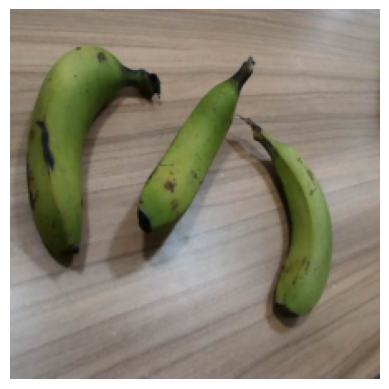

In [15]:
import matplotlib.pyplot as plt
import torch  # Assuming PyTorch is imported

# Grab one batch from the train loader
images, labels = next(iter(train_loader))

# Select the first image and label from the batch
image = images[0]  # Shape: [3, 224, 224]
label = labels[0].item()  # Convert tensor to int (0=Raw, 1=Ripe)

# Preprocess for display:
# 1. Permute to [H, W, C] (Matplotlib expects height, width, channels)
image = image.permute(1, 2, 0)  # Now [224, 224, 3]

# 2. Unnormalize (reverse the normalization applied in transforms)
# Using the same mean and std from your transforms
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
image = image * std + mean  # Unnormalize

# 3. Clip to [0, 1] range (in case of slight overflow) and convert to numpy
image = torch.clamp(image, 0, 1).numpy()

# Display
print(f"Label: {label} (0=Raw Banana, 1=Ripe Banana)")
plt.imshow(image)
plt.axis('off')  # Hide axes for cleaner look
plt.show()

In [16]:
if torch.cuda.is_available():
  print("GPU detected")
  device = torch.device("cuda")
else:
  print("No GPU detected")
  device = torch.device("cpu")

GPU detected


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report

def train_model(train_loader, val_loader, test_loader, epochs=5, lr=1e-3):

    model = BananaCNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

    # -------------------------------
    # Simple evaluation step (no evaluate.py)
    # -------------------------------
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    print("\nTEST SET RESULTS")
    print(classification_report(y_true, y_pred, target_names=["unripe", "ripe"]))

    return model


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# Original CNN
class BananaCNN(nn.Module):
    """Original model with MaxPooling"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x





In [18]:
# TODO create a network and move it to GPU
model = BananaCNN().to(device)

In [19]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
def get_accuracy_and_loss(model, loader, criterion):
  model.eval()
  my_loss = 0
  with torch.no_grad():
    correct = 0
    for data, target in loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      pred = output.argmax(dim=1)
      correct += pred.eq(target).sum().item()
      my_loss += criterion(output, target).item()
  return correct/len(loader.dataset), my_loss/len(loader.dataset)

In [56]:
# TODO train and print/store metrics
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.9885321100917431
Train loss: 0.0011295918138387738
Val accuracy: 0.9743589743589743
Val loss: 0.002893026752718093
Epoch 1 done.
Train accuracy: 0.9942660550458715
Train loss: 0.0005054144265580638
Val accuracy: 0.9267399267399268
Val loss: 0.016831654859126816
Epoch 2 done.
Train accuracy: 0.9977064220183486
Train loss: 0.00020059938894064023
Val accuracy: 0.8901098901098901
Val loss: 0.028342496920991073
Epoch 3 done.
Train accuracy: 0.9965596330275229
Train loss: 0.0001594828946867694
Val accuracy: 0.9963369963369964
Val loss: 0.0007048267861746653
Epoch 4 done.
Train accuracy: 1.0
Train loss: 1.592561998034557e-06
Val accuracy: 0.989010989010989
Val loss: 0.0008880285950265752
Epoch 5 done.
Train accuracy: 1.0
Train loss: 3.852845017053689e-07
Val accuracy: 0.9853479853479854
Val loss: 0.0013032807438711253
Epoch 6 done.
Train accuracy: 1.0
Train loss: 1.3273693649097067e-07
Val accuracy: 0.989010989010989
Val loss: 0.0014029453987966204


In [ ]:
# Evaluate BananaCNN with detailed metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import numpy as np

# Get predictions on test set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Calculate metrics
accuracy = accuracy_score(all_targets, all_preds)
precision, recall, f1, support = precision_recall_fscore_support(all_targets, all_preds, average='binary')

print("=" * 50)
print("BananaCNN Evaluation Metrics")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=['Raw', 'Ripe']))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")

# Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Raw', 'Ripe'], yticklabels=['Raw', 'Ripe'])
plt.title('BananaCNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model_metrics(model, test_loader, model_name="Model"):
    """
    Evaluate a model with detailed metrics including precision, recall, F1, and confusion matrix
    
    Args:
        model: The model to evaluate
        test_loader: DataLoader for test data
        model_name: Name to display in results
    """
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get predictions on test set
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, support = precision_recall_fscore_support(all_targets, all_preds, average='binary')

    print("=" * 50)
    print(f"{model_name} Evaluation Metrics")
    print("=" * 50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=['Raw', 'Ripe']))

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    print("\nConfusion Matrix:")
    print(cm)
    print(f"\nTrue Negatives:  {cm[0,0]}")
    print(f"False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}")
    print(f"True Positives:  {cm[1,1]}")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Raw', 'Ripe'], yticklabels=['Raw', 'Ripe'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

In [ ]:
# Example: Evaluate all models
# Just call the function with each model:

# Evaluate BananaCNN (original)
evaluate_model_metrics(model, test_loader, "BananaCNN")

# Evaluate BananaCNN_Deep
# evaluate_model_metrics(model2, test_loader, "BananaCNN_Deep")

# Evaluate BananaCNN_ResNet
# evaluate_model_metrics(model3, test_loader, "BananaCNN_ResNet")

# Evaluate ResNet18 Pretrained
# evaluate_model_metrics(model4, test_loader, "ResNet18_Pretrained")

# Evaluate BananaCNN_VGG
# evaluate_model_metrics(model5, test_loader, "BananaCNN_VGG")

# Evaluate BananaCNN_Strided
# evaluate_model_metrics(model6, test_loader, "BananaCNN_Strided")

# Evaluate BananaCNN_GlobalAvgPool
# evaluate_model_metrics(model7, test_loader, "BananaCNN_GlobalAvgPool")

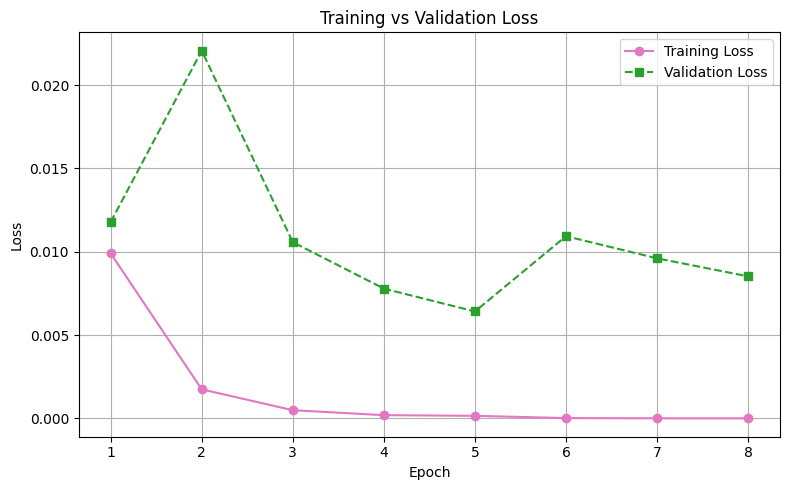

In [23]:
# TODO
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', color='tab:pink', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', color='tab:green', linestyle='--', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
class BananaCNN_Deep(nn.Module):
    """Deeper model with BatchNorm and Dropout"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

In [26]:
model2 = BananaCNN_Deep().to(device)

In [ ]:
optimizer = optim.Adam(model2.parameters(), lr=0.001)

In [28]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model2.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model2(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model2, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model2.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.4782110091743119
Train loss: 0.022736857175280196
Val accuracy: 0.45787545787545786
Val loss: 0.023096005121866863
Epoch 1 done.
Train accuracy: 0.4896788990825688
Train loss: 0.022509134895757798
Val accuracy: 0.45787545787545786
Val loss: 0.023199964137304397
Epoch 2 done.
Train accuracy: 0.48623853211009177
Train loss: 0.02260047231518894
Val accuracy: 0.46153846153846156
Val loss: 0.023229800519489106
Epoch 3 done.
Train accuracy: 0.5217889908256881
Train loss: 0.02260881265915862
Val accuracy: 0.46153846153846156
Val loss: 0.02321530458254692


In [32]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class BananaCNN_ResNet(nn.Module):
    """ResNet-style with skip connections"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [33]:
model3 = BananaCNN_ResNet().to(device)

In [ ]:
optimizer = optim.Adam(model3.parameters(), lr=0.001)

In [ ]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model3.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model3(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model3, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model3.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.5493119266055045
Train loss: 0.02345493285480989
Val accuracy: 0.5421245421245421
Val loss: 0.024084228080707593
Epoch 1 done.
Train accuracy: 0.5493119266055045
Train loss: 0.02284562068248014
Val accuracy: 0.5421245421245421
Val loss: 0.024084228080707593
Epoch 2 done.
Train accuracy: 0.5493119266055045
Train loss: 0.022840855455179828
Val accuracy: 0.5421245421245421
Val loss: 0.024084228080707593
Epoch 3 done.
Train accuracy: 0.5493119266055045
Train loss: 0.022677771952174127
Val accuracy: 0.5421245421245421
Val loss: 0.024084228080707593


In [37]:
def get_resnet18_pretrained():
    """Pretrained ResNet18 from torchvision"""
    model = models.resnet18(pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    return model


In [38]:
model4 = get_resnet18_pretrained().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 232MB/s]


In [ ]:
optimizer = optim.Adam(model4.parameters(), lr=0.001)

In [ ]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model4.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model4(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model4, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model4.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.45298165137614677
Train loss: 0.02706759798964229
Val accuracy: 0.46153846153846156
Val loss: 0.02957596032174079
Epoch 1 done.
Train accuracy: 0.4541284403669725
Train loss: 0.027055642610296197
Val accuracy: 0.46153846153846156
Val loss: 0.02957596032174079
Epoch 2 done.
Train accuracy: 0.4541284403669725
Train loss: 0.026964302866830738
Val accuracy: 0.46153846153846156
Val loss: 0.02957596032174079
Epoch 3 done.
Train accuracy: 0.4541284403669725
Train loss: 0.026918879479443263
Val accuracy: 0.46153846153846156
Val loss: 0.02957596032174079


In [41]:
class BananaCNN_VGG(nn.Module):
    """VGG-style with multiple 3x3 convolutions"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [42]:
model5 = BananaCNN_VGG().to(device)

In [ ]:
optimizer = optim.Adam(model5.parameters(), lr=0.001)

In [ ]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model5.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model5(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model5, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model5.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.4506880733944954
Train loss: 0.022294125835829917
Val accuracy: 0.45787545787545786
Val loss: 0.022885661858778734
Epoch 1 done.
Train accuracy: 0.4506880733944954
Train loss: 0.02229605498937292
Val accuracy: 0.45787545787545786
Val loss: 0.022885661858778734
Epoch 2 done.
Train accuracy: 0.4506880733944954
Train loss: 0.02229121552968244
Val accuracy: 0.45787545787545786
Val loss: 0.022885661858778734
Epoch 3 done.
Train accuracy: 0.4506880733944954
Train loss: 0.022295989437934455
Val accuracy: 0.45787545787545786
Val loss: 0.022885661858778734


In [46]:
class BananaCNN_Strided(nn.Module):
    """Uses strided convolutions instead of pooling layers"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)  # stride=2 reduces size
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [47]:
model6 = BananaCNN_Strided().to(device)

In [ ]:
optimizer = optim.Adam(model6.parameters(), lr=0.001)

In [ ]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model6.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model6(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model6, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model6.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.42775229357798167
Train loss: 0.0223171382185516
Val accuracy: 0.37362637362637363
Val loss: 0.02294104287039229
Epoch 1 done.
Train accuracy: 0.42775229357798167
Train loss: 0.02231319446902756
Val accuracy: 0.37362637362637363
Val loss: 0.02294104287039229
Epoch 2 done.
Train accuracy: 0.42775229357798167
Train loss: 0.022319489115968757
Val accuracy: 0.37362637362637363
Val loss: 0.02294104287039229
Epoch 3 done.
Train accuracy: 0.42775229357798167
Train loss: 0.022316552698612213
Val accuracy: 0.37362637362637363
Val loss: 0.02294104287039229


In [52]:
class BananaCNN_GlobalAvgPool(nn.Module):
    """Uses Global Average Pooling before classification"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Global avg pooling
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.global_pool(x)  # [batch, 256, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 256]
        x = self.fc(x)
        return x

In [53]:
model7 = BananaCNN_GlobalAvgPool().to(device)

In [ ]:
optimizer = optim.Adam(model7.parameters(), lr=0.001)

In [ ]:
 #TODO train and print/store metrics

criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(15):  # Can be arbitrarily large if we're early stopping
    model7.train()
    train_loss = 0
    correct = 0
    total_count = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model7(data)
        loss = criterion(output, target)
        train_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total_count += data.size(0)
        loss.backward()
        optimizer.step()

    val_accuracy, val_loss = get_accuracy_and_loss(model7, test_loader, criterion)
    print(f"Epoch {epoch} done.")
    train_accuracy = correct / total_count
    train_loss = train_loss / total_count
    print(f"Train accuracy: {train_accuracy}")
    train_accuracies.append(train_accuracy)
    print(f"Train loss: {train_loss}")
    train_losses.append(train_loss)
    print(f"Val accuracy: {val_accuracy}")
    val_accuracies.append(val_accuracy)
    print(f"Val loss: {val_loss}")

    val_losses.append(val_loss)
    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model7.state_dict(), 'best_model.pth')
      epochs_without_improve = 0
    else:
      epochs_without_improve += 1
      if epochs_without_improve >= patience:
        break

Epoch 0 done.
Train accuracy: 0.5493119266055045
Train loss: 0.022180907086494867
Val accuracy: 0.5421245421245421
Val loss: 0.022744772416768057
Epoch 1 done.
Train accuracy: 0.5493119266055045
Train loss: 0.02215972180486819
Val accuracy: 0.5421245421245421
Val loss: 0.022744772416768057
Epoch 2 done.
Train accuracy: 0.5493119266055045
Train loss: 0.02216039187864426
Val accuracy: 0.5421245421245421
Val loss: 0.022744772416768057
Epoch 3 done.
Train accuracy: 0.5493119266055045
Train loss: 0.022152634525517804
Val accuracy: 0.5421245421245421
Val loss: 0.022744772416768057


In [57]:
def evaluate_model(model, test_loader, device='cuda', model_name='Model'):
    """
    Comprehensive evaluation with multiple metrics
    Returns: dictionary with all metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = 100 * correct / total

    # Per-class metrics
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=[0, 1]
    )

    # Macro averages
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro'
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    results = {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision_unripe': precision[0],
        'recall_unripe': recall[0],
        'f1_unripe': f1[0],
        'precision_ripe': precision[1],
        'recall_ripe': recall[1],
        'f1_ripe': f1[1],
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

    return results

# ==================== Print Results Function ====================
def print_results(results):
    """Pretty print evaluation results"""
    print(f"\n{'='*60}")
    print(f"Results for: {results['model_name']}")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {results['accuracy']:.2f}%")
    print(f"\nPer-Class Metrics:")
    print(f"  Unripe - Precision: {results['precision_unripe']:.4f}, "
          f"Recall: {results['recall_unripe']:.4f}, F1: {results['f1_unripe']:.4f}")
    print(f"  Ripe   - Precision: {results['precision_ripe']:.4f}, "
          f"Recall: {results['recall_ripe']:.4f}, F1: {results['f1_ripe']:.4f}")
    print(f"\nMacro Averages:")
    print(f"  Precision: {results['precision_macro']:.4f}")
    print(f"  Recall: {results['recall_macro']:.4f}")
    print(f"  F1-Score: {results['f1_macro']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  {results['confusion_matrix']}")
    print(f"{'='*60}\n")

In [ ]:


# Original CNN
class BananaCNN(nn.Module):
    """Original model with MaxPooling"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ==================== Model 2: Deeper CNN with Batch Normalization ====================
class BananaCNN_Deep(nn.Module):
    """Deeper model with BatchNorm and Dropout"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# ==================== Model 5: Strided Convolutions (No Pooling) ====================
class BananaCNN_Strided(nn.Module):
    """Uses strided convolutions instead of pooling layers"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, stride=2, padding=1)  # stride=2 reduces size
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ==================== Model 6: Global Average Pooling ====================
class BananaCNN_GlobalAvgPool(nn.Module):
    """Uses Global Average Pooling before classification"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # Global avg pooling
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = F.relu(self.conv4(x))
        x = self.global_pool(x)  # [batch, 256, 1, 1]
        x = x.view(x.size(0), -1)  # [batch, 256]
        x = self.fc(x)
        return x

# ==================== Model 7: ResNet-Style with Skip Connections ====================
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class BananaCNN_ResNet(nn.Module):
    """ResNet-style with skip connections"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ==================== Model 8: VGG-Style (Deeper with small filters) ====================
class BananaCNN_VGG(nn.Module):
    """VGG-style with multiple 3x3 convolutions"""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ==================== Model 9: Transfer Learning - ResNet18 ====================
def get_resnet18_pretrained():
    """Pretrained ResNet18 from torchvision"""
    model = models.resnet18(pretrained=True)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 2)
    return model

# ==================== Model 10: Transfer Learning - MobileNetV2 ====================
def get_mobilenet_pretrained():
    """Pretrained MobileNetV2 (lightweight for mobile deployment)"""
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.last_channel, 2)
    return model

# ==================== Comprehensive Evaluation Function ====================
def evaluate_model(model, test_loader, device='cuda', model_name='Model'):
    """
    Comprehensive evaluation with multiple metrics
    Returns: dictionary with all metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = 100 * correct / total

    # Per-class metrics
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=[0, 1]
    )

    # Macro averages
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro'
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    results = {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision_unripe': precision[0],
        'recall_unripe': recall[0],
        'f1_unripe': f1[0],
        'precision_ripe': precision[1],
        'recall_ripe': recall[1],
        'f1_ripe': f1[1],
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

    return results

# ==================== Print Results Function ====================
def print_results(results):
    """Pretty print evaluation results"""
    print(f"\n{'='*60}")
    print(f"Results for: {results['model_name']}")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {results['accuracy']:.2f}%")
    print(f"\nPer-Class Metrics:")
    print(f"  Unripe - Precision: {results['precision_unripe']:.4f}, "
          f"Recall: {results['recall_unripe']:.4f}, F1: {results['f1_unripe']:.4f}")
    print(f"  Ripe   - Precision: {results['precision_ripe']:.4f}, "
          f"Recall: {results['recall_ripe']:.4f}, F1: {results['f1_ripe']:.4f}")
    print(f"\nMacro Averages:")
    print(f"  Precision: {results['precision_macro']:.4f}")
    print(f"  Recall: {results['recall_macro']:.4f}")
    print(f"  F1-Score: {results['f1_macro']:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"  {results['confusion_matrix']}")
    print(f"{'='*60}\n")

# ==================== Plot Confusion Matrix ====================
def plot_confusion_matrix(results, save_path=None):
    """Plot confusion matrix"""
    plt.figure(figsize=(8, 6))
    sns.heatmap(results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Unripe', 'Ripe'],
                yticklabels=['Unripe', 'Ripe'])
    plt.title(f"Confusion Matrix - {results['model_name']}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ==================== Compare Multiple Models ====================
def compare_models(results_list):
    """
    Compare multiple models side by side
    results_list: list of result dictionaries from evaluate_model
    """
    print(f"\n{'='*100}")
    print(f"{'Model':<30} {'Accuracy':<12} {'F1-Macro':<12} {'Precision':<12} {'Recall':<12}")
    print(f"{'='*100}")

    for results in results_list:
        print(f"{results['model_name']:<30} "
              f"{results['accuracy']:<12.2f} "
              f"{results['f1_macro']:<12.4f} "
              f"{results['precision_macro']:<12.4f} "
              f"{results['recall_macro']:<12.4f}")

    print(f"{'='*100}\n")

    # Plot comparison
    model_names = [r['model_name'] for r in results_list]
    accuracies = [r['accuracy'] for r in results_list]
    f1_scores = [r['f1_macro'] * 100 for r in results_list]

    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy')
    rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score')

    ax.set_xlabel('Models')
    ax.set_ylabel('Percentage')
    ax.set_title('Model Comparison: Accuracy and F1-Score')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==================== Example Usage ====================
def main():
    """Example of how to use all models and evaluation"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Assume you have a test_loader already created
    # test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Dictionary of all models to test
    models_dict = {
        'Original MaxPool': BananaCNN(),
        'AvgPool': BananaCNN_AvgPool(),
        'Mixed Pool': BananaCNN_MixedPool(),
        'Deep BN+Dropout': BananaCNN_Deep(),
        'Strided Conv': BananaCNN_Strided(),
        'Global AvgPool': BananaCNN_GlobalAvgPool(),
        'ResNet-Style': BananaCNN_ResNet(),
        'VGG-Style': BananaCNN_VGG(),
        'ResNet18 Pretrained': get_resnet18_pretrained(),
        'MobileNetV2': get_mobilenet_pretrained()
    }

    results_list = []

    # Evaluate each model
    for model_name, model in models_dict.items():
        print(f"\nEvaluating {model_name}...")

        # Load trained weights (you need to train these first)
        # model.load_state_dict(torch.load(f'{model_name}_weights.pth'))

        model = model.to(device)
        results = evaluate_model(model, test_loader, device, model_name)
        print_results(results)
        plot_confusion_matrix(results, save_path=f'{model_name}_cm.png')
        results_list.append(results)

    # Compare all models
    compare_models(results_list)

if __name__ == '__main__':
    main()